# Workbench Execution Model

This deep dive focuses on Workbench execution model - the way Workbench programs are compiled and executed on quantum simulators and, in the future, on PsiQuantum fault-tolerant quantum computers.

## Workbench: an extensible library for quantum programming

Workbench is a Python library which allows you to incorporate quantum computation into your Python programs.
It treats the quantum processing unit (QPU) as a coprocessor: the main program is executed on a CPU (a classical computer), and only the quantum instructions are sent to the QPU.
This means that your Workbench programs have access to any "classical" Python libraries you need: not only the built-in Python libraries but commonly used packages for scientific computations such as numpy and scipy, as well as domain-specific packages.

Importantly, Workbench is designed to be easily extensible. It includes a set of quantum libraries and filters - classical tools that process quantum instructions generated by a Workbench program (more on that in the next sections). You can write not only your own quantum libraries but also new filters which you can then use to change the way your programs are compiled and executed. For example, you can write filters to change the way certain gates are decomposed into sequences of other gates, to run your Workbench program on a simulator from a different quantum software development kit, and so on.


## QPU: a configurable coprocessor

Workbench treats the quantum processing unit (QPU) as a coprocessor used by the classical computer. Workbench programs start by creating a [QPU object](../tutorials/QPU-Object.ipynb) 
and allocating [Qubits objects](../tutorials/Qubits-Data-Type.ipynb). Then, they perform quantum operations, such as applying gates and measurements, using methods of the Qubits objects (and, sometimes, methods of the QPU object directly). Effectively, the QPU object processes all quantum instructions in your Workbench program. It also handles certain commands that are not quantum instructions themselves, such as drawing circuits, [printing debugging information](../tutorials/Testing-Debugging.ipynb) about program execution, and getting resource estimates.

The QPU object configures the way the program will be processed by setting up the [*filter pipeline*](../tutorials/Configuring-Execution.ipynb) - a sequence of tools ("filters") that each process the quantum instructions in a certain way specific to that filter. You can run the same Workbench program use different filter pipelines to get different results. For example, you can run a small instance of your problem on a full state simulator, draw the circuit for a larger problem instance, or compare the results of using different compilation filters for the same program.

## Program execution: an example

Let's take a look at a very small program that prepares the state $\tfrac1{\sqrt2}|000\rangle + \tfrac1{\sqrt2}|1++\rangle$ using a Hadamard gate followed by two controlled Hadamard gates and then measures all qubits.

> Notice that the program is written as a Python function that takes the QPU object as an argument. This way, we'll be able to run the same program on several QPU objects with different configurations easily.

In [1]:
from psiqdk.workbench import QPU, Qubits

def example_circuit(qpu: QPU) -> int:
    reg = Qubits(3, "reg", qpu=qpu)
    reg[0].had()
    reg[1:].had(cond=reg[0])
    qpu.print_state_vector()
    return reg.read()

qpu = QPU(num_qubits=3, filters=['>>buffer>>', '>>state-vector-sim>>'])
res = example_circuit(qpu)
print(res)


|reg>
|0>    0.707107+0.000000j
|1>    0.353553+0.000000j
|3>    0.353553+0.000000j
|5>    0.353553+0.000000j
|7>    0.353553+0.000000j
5


Our example function does the following things: 

1. Allocates two qubits on the given QPU by creating a Qubits object.
2. Applies gates and measurements using methods of the Qubits object.
3. Calls the `print_state_vector()` method of the QPU object to print the state of the simulator before measurement.

The main program creates a QPU object with two filters: 

* The `>>buffer>>` filter records the instructions it receives and passes them to the next filter unchanged.
* The `>>state-vector-sim>>` filter performs state vector simulation of the instructions it receives.

Let's see how the steps of this program are represented in the QPU object. To do this, we will use two tools:

* The `draw()` method of the QPU object draws the circuit representation of the quantum instructions emitted by your program.
* The `print_instructions()` method of the QPU object prints a list of quantum instructions captured by the `>>buffer>>` filter.

qc.reset(num_qubits=3)
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.had(target_mask=0x1)
qc.had(target_mask=0x6, condition_mask=0x1)
qc.read(target_mask=0x7, result=0, set_flag=2)



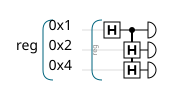

In [2]:
qpu.print_instructions(format='asm')
qpu.draw()

You can see that there are five instructions in the list: 

* `qc.reset` is the implicit `reset()` call done during QPU initialization.
* `qc.qubits_alloc` is the qubits allocation instruction.
* Two `qc.had` instructions correspond to the Hadamard gate and the pair of controlled Hadamard gates. Notice that each call to `had()` method of the Qubits object generated a single instruction, despite the fact that mathematically each gate is represented separately.
* `qc.read` is the measurement instruction. Again, each of the three qubits is measured separately (as opposed to a multi-qubit measurement), but this is represented as a single instruction.

Each filter in the filter pipeline processes each instruction. Utility filters, such as `>>buffer>>`, keep track of the instructions they receive but not change them or do anything interesting with them. Simulator filters, such as `>>qpu>>`, use the instructions they receive to simulate their effect on the quantum state of the program. Compilation filters, such as `>>single-control-filter>>` we'll see later, change the internal representation of the program, replacing certain instructions with others, allocating additional qubits, and so on.

You can also see that the `print_state_vector` call didn't generate an instruction. This method is not part of the quantum program as such, but rather a command for the QPU to print the state of the simulator (as long as one of the filters is a simulator). If we remove the `>>qpu>>` filter from the list of filters used to initialize the QPU object, the same program will be processed without simulation. We'll still be able to draw its circuit and fetch the list of instructions, but we will not get the state vector or non-zero measurement results.

(no state vector to print)
0


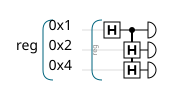

In [3]:
qpu = QPU(num_qubits=3, filters=['>>buffer>>'])
res = example_circuit(qpu)
print(res)
qpu.draw()

Now, let's add a compilation step to the list of filters.

`>>single-control-filter>>` decomposes controlled rotations (including controlled Hadamard gates) into sequences of uncontrolled single-qubit gates and controlled $X$ gates. If we add it to the beginning of the list of filters, the simulation results will remain unchanged. However, the internal representation of the program will change: you can see that the pair of controlled Hadamard gates was replaced with a longer decomposition both in the circuit diagram and in the list of instructions. (If you look closely into the list of instructions, you'll notice that the matching gates in the decomposition are also paired: there is one instruction for the pair of $S$ gates, one for the pair of $H$ gates, and so on.)

|reg>
|0>    0.707107+0.000000j
|1>    0.353553+0.000000j
|3>    0.353553+0.000000j
|5>    0.353553+0.000000j
|7>    0.353553+0.000000j
3
qc.reset(num_qubits=3)
qc.qubits_alloc(target_mask=0x7, label="reg")
qc.had(target_mask=0x1)
qc.s(target_mask=0x6)
qc.had(target_mask=0x6)
qc.t(target_mask=0x6)
qc.x(target_mask=0x6, condition_mask=0x1)
qc.t_inv(target_mask=0x6)
qc.had(target_mask=0x6)
qc.s_inv(target_mask=0x6)
qc.read(target_mask=0x7, result=0, set_flag=2)



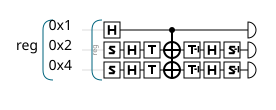

In [4]:
qpu = QPU(num_qubits=3, filters=['>>single-control-filter>>', '>>buffer>>', '>>state-vector-sim>>'])
res = example_circuit(qpu)
print(res)
qpu.print_instructions(format='asm')
qpu.draw()


## Pre-compilation vs just-in-time compilation

The state preparation example above featured a very simple fixed circuit with no classical logic. This means that it can be pre-compiled entirely before it starts executing on a simulator.

In general, though, quantum programs often depend on measurement outcomes that are not known until the program starts running. For example, efficient QROM uncompute generates the necessary gates based on measurement outcomes using non-trivial classical logic. 

Workbench combines pre-compilation with just-in-time compilation as needed for each program. Often this means that it pre-compiles the parts of the program until the first time measurement outcomes define the path the program should take, and issues new gates "just in time" after that. This process happens under the hood, without quantum application developer having to guide it.